In [ ]:
# !pip install xgboost -q

In [12]:
# import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report,precision_score,f1_score,recall_score
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier

In [5]:
# Load Data set
df=sns.load_dataset("iris")
df.head(2)

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa


<Axes: xlabel='sepal_length', ylabel='sepal_width'>

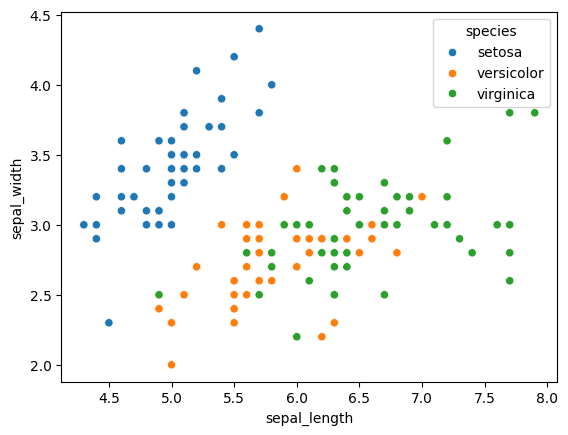

In [6]:
# Plot the data as scatter 

sns.scatterplot(x="sepal_length", y="sepal_width", hue="species", data=df)

In [9]:
# Split the data into X and y
X=df.drop('species', axis=1)
y=df['species']

# train test split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [22]:
%%time

# Train model
model = DecisionTreeClassifier()
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluate
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
print(f"Precision: {precision_score(y_test, y_pred, average='micro')}")
print(f"Recall: {recall_score(y_test, y_pred, average='micro')}")
print(f"F1 Score: {f1_score(y_test, y_pred, average='micro')}")

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0
CPU times: total: 46.9 ms
Wall time: 18.4 ms


# Random Forest Model

In [23]:
%%time
rf=RandomForestClassifier()
rf.fit(X_train, y_train)
y_pred=rf.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
print(f"Precision: {precision_score(y_test, y_pred, average='micro')}")
print(f"Recall: {recall_score(y_test, y_pred, average='micro')}")
print(f"F1 Score: {f1_score(y_test, y_pred, average='micro')}")

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0
CPU times: total: 141 ms
Wall time: 215 ms


# XGBoost Mdel

In [24]:
%%time
xgb=XGBClassifier()
xgb.fit(X_train, y_train)
y_pred=xgb.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
print(f"Precision: {precision_score(y_test, y_pred, average='micro')}")
print(f"Recall: {recall_score(y_test, y_pred, average='micro')}")
print(f"F1 Score: {f1_score(y_test, y_pred, average='micro')}")


Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0
CPU times: total: 250 ms
Wall time: 114 ms


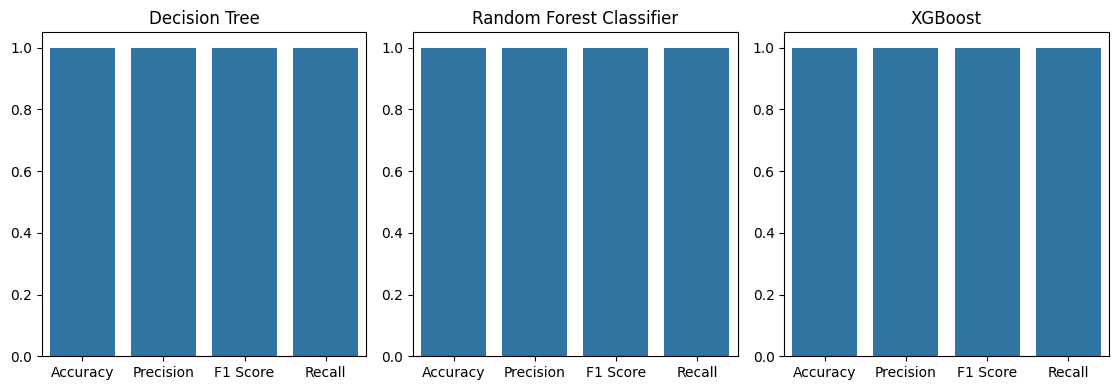

In [32]:
plt.figure(figsize=(15,4))

plt.subplot(1,4,1)
sns.barplot(
    x=['Accuracy','Precision','F1 Score','Recall'],
    y=[
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred, average='weighted'),
        f1_score(y_test, y_pred, average='weighted'),
        recall_score(y_test, y_pred, average='weighted')
    ]
)
plt.title('Decision Tree')

plt.subplot(1,4,2)
sns.barplot(
    x=['Accuracy','Precision','F1 Score','Recall'],
    y=[
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred, average='weighted'),
        f1_score(y_test, y_pred, average='weighted'),
        recall_score(y_test, y_pred, average='weighted')
    ]
)
plt.title('Random Forest Classifier')

plt.subplot(1,4,3)
sns.barplot(
    x=['Accuracy','Precision','F1 Score','Recall'],
    y=[
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred, average='weighted'),
        f1_score(y_test, y_pred, average='weighted'),
        recall_score(y_test, y_pred, average='weighted')
    ]
)
plt.title('XGBoost')

plt.tight_layout()
plt.show()


----